In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import zarr

from careamics.careamist_v2 import CAREamistV2
from careamics.config.ng_factories import create_advanced_n2v_config

In [2]:
np.prod((667, 76, 546, 585))


np.int64(16191531720)

In [3]:
np.prod((200, 76, 546, 585))

np.int64(4855032000)

In [4]:
array = zarr.open_array("file:///project/careamics/data/eth/data_zarr/002/data.zarr", path="0")

In [5]:
array.shape

(667, 2, 76, 546, 585)

In [6]:
train_data = array[:400:8, 0]
val_data = array[420:424, 0]

In [7]:
train_data.size

1213758000

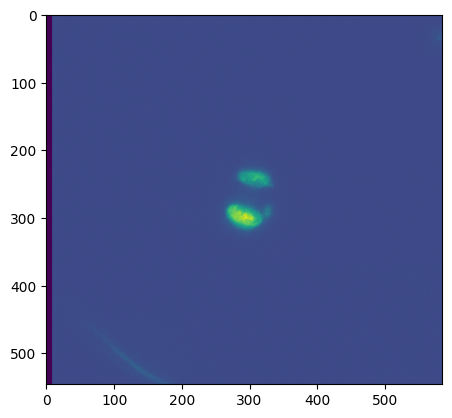

In [8]:
z = 32
plt.imshow(train_data[25, z])

In [9]:
config = create_advanced_n2v_config(
    "with_filtering",
    "array",
    patch_size=(64, 64, 64),
    batch_size=16,
    axes="TZYX",
    num_epochs=20,
    # logger="wandb",
    checkpoint_params={
        # "save_top_k": 10
    }
)
config.data_config.patch_filter={
    "name": "shannon",
    "threshold": 3.2
}

In [10]:
careamist = CAREamistV2(config)
t = time.time()
careamist.train(train_data=train_data, val_data=val_data)
total_train_time = time.time() - t
print("Total train time", total_train_time)

No working directory provided. Using current working directory: /home/melisande.croft/Documents/Repos/careamics/src/careamics/dataset_ng.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA A40-16Q') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


TypeError: ShannonPatchFilter.__init__() got an unexpected keyword argument 'filter_ref_channel'

In [9]:
config = create_advanced_n2v_config(
    "with_out_filtering",
    "array",
    patch_size=(64, 64, 64),
    batch_size=16,
    axes="TZYX",
    num_epochs=10,
    logger="wandb"
)

In [10]:
careamist = CAREamistV2(config)
t = time.time()
careamist.train(train_data=train_data, val_data=val_data)
total_train_time = time.time() - t
print("Total train time", total_train_time)

No working directory provided. Using current working directory: /home/melisande.croft/Documents/Repos/careamics/src/careamics/dataset_ng.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA A40-16Q') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: Currently logged in as: milly-croft (milly-croft-human-technopole) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Computing mean/std statistics: 100%|██████████| 4650/4650 [00:05<00:00, 808.06it/s]
/home/melisande.croft/Documents/Repos/careamics/.venv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /home/melisande.croft/Documents/Repos/careamics/src/careamics/dataset_ng/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | model   | UNet             | 997 K  | train
1 | metrics | MetricCollection | 0      | train
-----------------------------------------------------
997 K     Trainable params
0         Non-trainable params
997 K     Total params
3.991     Total estimated model params size (MB)
41        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/melisande.croft/Documents/Repos/careamics/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/home/melisande.croft/Documents/Repos/careamics/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Total train time 1183.4212305545807


In [ ]:
# checkpoint_path = Path("/home/melisande.croft/Documents/Repos/careamics/src/careamics/dataset_ng/checkpoints/with_filtering_09_step_920.ckpt")
wf_e = 9
wf_s = 920
checkpoint_path = Path(f"/home/melisande.croft/Documents/Repos/careamics/src/careamics/dataset_ng/checkpoints/with_filtering_{wf_e:02d}_step_{wf_s}.ckpt")
careamist = CAREamistV2(checkpoint_path=checkpoint_path)
prediction_w_filtering = careamist.predict(val_data[[0]], batch_size=1, tile_size=(128, 128, 128), tile_overlap=(48, 48, 48))

In [ ]:
# checkpoint_path = Path("/home/melisande.croft/Documents/Repos/careamics/src/careamics/dataset_ng/checkpoints/with_out_filtering_08_step_2619.ckpt")
wof_e = 8
wof_s = 2619
checkpoint_path = Path(f"/home/melisande.croft/Documents/Repos/careamics/src/careamics/dataset_ng/checkpoints/with_out_filtering_{wof_e:02d}_step_{wof_s}.ckpt")
careamist = CAREamistV2(checkpoint_path=checkpoint_path)
prediction_wo_filtering = careamist.predict(val_data[[0]], batch_size=1, tile_size=(128, 128, 128), tile_overlap=(48, 48, 48))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 12), constrained_layout=True)
axes[0].imshow(val_data[0, 32, 180:400, 180:400])
axes[1].imshow(prediction_w_filtering[0][0][0, 32, 180:400, 180:400])
axes[2].imshow(prediction_wo_filtering[0][0][0, 32, 180:400, 180:400])
axes[0].plot([0, 400-180], [360-180, 360-180], "tab:blue")
axes[0].set_xlim(0, 400-180)
axes[1].plot([0, 400-180], [360-180, 360-180], "tab:orange")
axes[1].set_xlim(0, 400-180)
axes[2].plot([0, 400-180], [360-180, 360-180], "tab:green")
axes[2].set_xlim(0, 400-180)
axes[0].set_title("Input")
axes[1].set_title(f"W Filtering e:{wf_e}, s:{wf_s}")
axes[2].set_title(f"W/O Filtering e:{wof_e}, s:{wof_s}")

In [ ]:
plt.plot(val_data[0, 32, 360, 180:400], label="input")
plt.plot(prediction_w_filtering[0][0][0, 32, 360, 180:400], label=f"w_filtering e:{wf_e}, s:{wf_s}")
plt.plot(prediction_wo_filtering[0][0][0, 32, 360, 180:400], label=f"wo_filtering e:{wof_e}, s:{wof_s}")
plt.legend()

In [ ]:
checkpoint_path = Path("/home/melisande.croft/Documents/Repos/careamics/src/careamics/dataset_ng/checkpoints/last-v1.ckpt")
careamist = CAREamistV2(checkpoint_path=checkpoint_path)
prediction_w_filtering = careamist.predict(val_data[[0]], batch_size=1, tile_size=(128, 128, 128), tile_overlap=(48, 48, 48))

In [ ]:
checkpoint_path = Path("/home/melisande.croft/Documents/Repos/careamics/src/careamics/dataset_ng/checkpoints/last-v2.ckpt")
careamist = CAREamistV2(checkpoint_path=checkpoint_path)
prediction_wo_filtering = careamist.predict(val_data[[0]], batch_size=1, tile_size=(128, 128, 128), tile_overlap=(48, 48, 48))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 12), constrained_layout=True)
axes[0].imshow(val_data[0, 32, 180:400, 180:400])
axes[1].imshow(prediction_w_filtering[0][0][0, 32, 180:400, 180:400])
axes[2].imshow(prediction_wo_filtering[0][0][0, 32, 180:400, 180:400])
axes[0].plot([0, 400-180], [360-180, 360-180], "tab:blue")
axes[0].set_xlim(0, 400-180)
axes[1].plot([0, 400-180], [360-180, 360-180], "tab:orange")
axes[1].set_xlim(0, 400-180)
axes[2].plot([0, 400-180], [360-180, 360-180], "tab:green")
axes[2].set_xlim(0, 400-180)
axes[0].set_title("Input")
axes[1].set_title("W Filtering last")
axes[2].set_title("W/O Filtering last")

In [ ]:
plt.plot(val_data[0, 32, 360, 180:400], label="input")
plt.plot(prediction_w_filtering[0][0][0, 32, 360, 180:400], label="w_filtering last")
plt.plot(prediction_wo_filtering[0][0][0, 32, 360, 180:400], label="wo_filtering last")
plt.legend()